# BERT Embeddings and Clustering
### IDS 570: Text as Data — Final Project

---

## Overview

This notebook generates contextual word embeddings for every occurrence of the word *equity* in the health equity corpus using BERT (Bidirectional Encoder Representations from Transformers). Unlike traditional word frequency methods such as TF-IDF, BERT produces a different numerical representation for the same word depending on its surrounding context. This allows us to detect whether *equity* is being used differently across document types — for example, as a structural/justice concept versus as a distributional/access measure.

The embeddings are then grouped using K-Means clustering and the results are exported for interactive visualization in Tableau.

## Objectives

- Load the full sentence corpus and filter to equity-containing sentences
- Reconstruct the ±1 sentence context window around each equity occurrence
- Generate a 768-dimensional BERT embedding for the word *equity* in each context
- Save embeddings to disk to avoid rerunning the expensive computation
- Apply K-Means clustering with silhouette score selection to find the optimal number of semantic groups
- Inspect representative examples from each cluster to interpret their meaning
- Export results for Tableau visualization

## Dataset Description

The input data is `full_sentence_corpus.csv`, produced by the data extraction notebook. Each row represents one sentence from a public health document, with metadata including the document category, source label, title, and flags indicating whether the sentence contains equity-related terms.

This notebook filters the corpus to only the sentences where `contains_equity = True` (approximately 4,060 rows), then reconstructs the ±1 sentence context window by joining `prev_sentence`, `sentence_text`, and `next_sentence`. This wider window gives BERT more context to work with when generating embeddings.

**Input:** `01_data/full_sentence_corpus.csv`

**Outputs:**
- `01_data/equity_embeddings.npy` — NumPy array of BERT embeddings (shape: n_sentences × 768)
- `01_data/equity_embeddings_meta.csv` — metadata for each embedded sentence
- `01_data/equity_tableau.csv` — final output with cluster assignments for Tableau

## Key Considerations

- **Model choice:** We use PubMedBERT `microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract`, a domain-specific BERT model pre-trained exclusively on PubMed abstracts and biomedical text. PubMedBERT was selected because all five document types in our corpus operate within the health domain — including policy, NGO, and news documents which use health-specific terminology such as disparities, SDOH, Medicaid, and health outcomes. A domain-specific model is therefore more appropriate than a general English model for capturing semantic variation in health equity language.
- **Embedding extraction:** Rather than using the final hidden layer only, we average the last four hidden layers at the equity token position. This is a standard technique that produces richer semantic representations.
- **Silhouette scores:** The silhouette scores for our corpus are low (around 0.09), indicating that the clusters overlap considerably. This is itself an interpretable finding — equity language in public health documents varies on a continuum rather than falling into two clean discrete senses.
- **GPU recommended:** Embedding generation is done on CPU and takes 6 mins. 
- **Reproducibility:** Embeddings are saved to disk after generation. Subsequent runs can reload them directly without rerunning the model.

## Outcome

The notebook produces cluster assignments for all equity sentences in the corpus. The cluster distribution by document type is examined to assess whether academic, federal policy, NGO, state/local, and news/commentary documents tend to use *equity* in systematically different ways. These findings contribute to Step 3 of the project (Contextual Meaning with BERT) and feed into the synthesis section.

---
## Step 1 — Install Dependencies

In [1]:
# Run once — installs HuggingFace Transformers and PyTorch
!pip install -q transformers torch

---
## Step 2 — Load Data and Reconstruct Context Windows

We load the full sentence corpus, filter to equity-containing sentences, and reconstruct the ±1 sentence context window. The context window gives BERT more surrounding text to work with when generating the embedding for the word *equity*.

In [2]:
import pandas as pd
import numpy as np

# Load full corpus and filter to equity sentences only
df_full = pd.read_csv("../01_data/full_sentence_corpus.csv")
df = df_full[df_full["contains_equity"] == True].copy().reset_index(drop=True)

# Reconstruct ±1 sentence context window
df["context_window"] = (
    df["prev_sentence"].fillna("")
    + " "
    + df["sentence_text"]
    + " "
    + df["next_sentence"].fillna("")
).str.strip()

print(f"Total equity sentences: {len(df):,}")
print("\nBreakdown by category:")
print(df["category"].value_counts())

Total equity sentences: 4,060

Breakdown by category:
category
state_local        2202
federal_policy     1036
ngo_nonprofit       630
academic            140
news_commentary      52
Name: count, dtype: int64


--
## Step 3 — Load BERT Model

We load `PubMedBERT` (`microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract`) 
from HuggingFace.

Two components are needed:

- **Tokenizer** — converts raw text into token IDs that BERT can process
- **Model** — the 12-layer transformer that generates contextual embeddings

The model is run on CPU

In [3]:
import torch
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

print(f"Using device: {device}")
print("BERT model loaded successfully.")

/Users/sebinescaria/miniforge3/envs/equity_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 25572.67it/s]
BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_re

Using device: cpu
BERT model loaded successfully.


---
## Step 4 — Generate BERT Embeddings

For each equity context window, we:
1. Tokenize the text using WordPiece tokenization
2. Locate the token position(s) of the word *equity*
3. Pass the text through all 12 BERT layers
4. Extract the last 4 hidden layers and average them at the equity token position
5. Return a single 768-dimensional vector representing the meaning of *equity* in that context

Embeddings are saved to disk after generation so this step does not need to be rerun.

In [4]:
from tqdm import tqdm


def get_equity_embedding(text, tokenizer, model, device, max_length=256):
    """Extract a contextual BERT embedding for the word 'equity' in text."""
    text_lower = text.lower()
    if "equity" not in text_lower:
        return None

    # Tokenize input
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=max_length,
        truncation=True,
        padding="max_length",
    )

    # Find positions of equity tokens
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    equity_positions = [i for i, t in enumerate(tokens) if "equity" in t.lower()]

    if not equity_positions:
        return None

    # Move to device and run model
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    # Average last 4 hidden layers at equity token position(s)
    hidden_states = outputs.hidden_states
    last_4 = torch.stack(hidden_states[-4:])
    avg_last_4 = last_4.mean(dim=0)

    equity_embeddings = [
        avg_last_4[0, pos, :].cpu().numpy() for pos in equity_positions
    ]
    return np.mean(equity_embeddings, axis=0)


# Generate embeddings for all equity sentences
embeddings = []
valid_indices = []

print(f"Generating embeddings for {len(df):,} equity sentences...")

for i in tqdm(range(len(df))):
    text = str(df["context_window"].iloc[i])
    emb = get_equity_embedding(text, tokenizer, model, device)
    if emb is not None:
        embeddings.append(emb)
        valid_indices.append(i)

embeddings = np.array(embeddings)
df_valid = df.iloc[valid_indices].reset_index(drop=True)

print(f"\nEmbeddings generated: {len(embeddings):,}")
print(f"Embedding dimension:  {embeddings.shape[1]}")

# Save to disk
np.save("../01_data/equity_embeddings.npy", embeddings)
df_valid.to_csv("../01_data/equity_embeddings_meta.csv", index=False)
print("\nSaved embeddings to 01_data/")

Generating embeddings for 4,060 equity sentences...


100%|██████████| 4060/4060 [05:44<00:00, 11.78it/s]


Embeddings generated: 4,040
Embedding dimension:  768

Saved embeddings to 01_data/


This process was run on 4,060 equity sentences, producing 4,040 
valid embeddings. The 20 sentences skipped represent cases where 
the tokenizer did not locate *equity* as a distinct token — a 
known edge case in WordPiece tokenization. Embeddings are saved 
to disk after generation so this step does not need to be rerun.

**Runtime:** approximately 6 minutes on CPU.

---
## Step 5 — K-Means Clustering

We apply K-Means clustering to the normalized BERT embeddings to group equity occurrences by semantic similarity. The optimal number of clusters (k) is selected by maximizing the silhouette score, which measures how well each point fits its assigned cluster versus neighboring clusters.

We test k = 2 through k = 5 and report the silhouette score for each. The cross-tabulation by document type shows whether different institutional sources tend to use *equity* in systematically different ways.

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

# Normalize embeddings to unit length before clustering
embeddings_norm = normalize(embeddings)

# Test k = 2 to 5 and select best by silhouette score
print("Selecting optimal k by silhouette score...\n")
silhouette_scores = {}

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings_norm)
    score = silhouette_score(embeddings_norm, labels, sample_size=2000, random_state=42)
    silhouette_scores[k] = score
    print(f"  k={k}: silhouette score = {score:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest k: {best_k} (score: {silhouette_scores[best_k]:.4f})")

# Fit final model with best k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(embeddings_norm)
df_valid["cluster"] = cluster_labels

print("\nCluster distribution:")
print(df_valid["cluster"].value_counts().sort_index())

print("\nCluster distribution by document type:")
print(pd.crosstab(df_valid["cluster"], df_valid["category"]))

Selecting optimal k by silhouette score...

  k=2: silhouette score = 0.1840
  k=3: silhouette score = 0.1068
  k=4: silhouette score = 0.0712
  k=5: silhouette score = 0.0729

Best k: 2 (score: 0.1840)

Cluster distribution:
cluster
0    2612
1    1428
Name: count, dtype: int64

Cluster distribution by document type:
category  academic  federal_policy  news_commentary  ngo_nonprofit  \
cluster                                                              
0              127             722               19            366   
1               13             310               33            257   

category  state_local  
cluster                
0                1378  
1                 815  


**Silhouette scores:** The silhouette score for our corpus is 0.1840 for k=2, indicating moderate but meaningful cluster separation. While not a high score, it suggests equity language varies on a continuum rather than falling into two perfectly discrete senses — an interpretable finding in itself.

The cross-tabulation by document type reveals a striking pattern: 
academic sentences concentrate overwhelmingly in Cluster 0 (127 out of 
140 academic sentences, or 91%), while news commentary sentences lean 
relatively more toward Cluster 1 (33 out of 52, or 63%). This 
distributional asymmetry provides initial support for the hypothesis 
that academic and non-academic document types use equity in 
systematically different ways. 

---
### Interpretation — Cosine Similarity Between Document Types

The cosine similarity matrix reveals how semantically similar the average 
PubMedBERT equity embeddings are across document types. All values are 
high (ranging from 0.935 to 0.996), indicating that equity language shares 
a common semantic core across all institutional contexts — a finding 
consistent with all document types operating within the same health domain.

However, meaningful differences emerge within this high-similarity range:

- **Federal policy and state/local** are the most similar pair (0.996), 
  suggesting these two government document types use equity in nearly 
  identical semantic contexts — consistent with shared administrative 
  and regulatory language.

- **State/local and NGO** are equally similar (0.996), indicating that 
  nonprofit advocacy organizations and state health departments share 
  considerable equity vocabulary — likely reflecting the close 
  relationship between NGO advocacy work and state policy implementation.

- **Academic and news commentary** are the least similar pair (0.935), 
  suggesting these two document types occupy the most distinct semantic 
  positions in the embedding space. Academic texts use equity in 
  theoretical and methodological contexts, while news commentary embeds 
  it in narrative and journalistic contexts.

- **Academic texts are consistently less similar to all other types** 
  (0.935–0.984) than non-academic types are to each other (0.969–0.996), 
  providing quantitative support for H1 — that academic equity language 
  is semantically distinct from institutional and media usage.

This similarity analysis complements the K-Means clustering results: 
while clustering groups individual sentences, the similarity matrix 
operates at the document-type level, confirming that the semantic 
differences are systematic across institutional categories rather than 
driven by individual outlier sentences.

In [6]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Average embedding per document type
categories = df_valid["category"].unique()
category_embeddings = {}

for cat in categories:
    mask = df_valid["category"] == cat
    category_embeddings[cat] = embeddings_norm[mask].mean(axis=0)

# Compute pairwise cosine similarity between document types
cats = list(category_embeddings.keys())
sim_matrix = np.zeros((len(cats), len(cats)))

for i, cat_i in enumerate(cats):
    for j, cat_j in enumerate(cats):
        sim_matrix[i, j] = cosine_similarity(
            [category_embeddings[cat_i]], [category_embeddings[cat_j]]
        )[0][0]

sim_df = pd.DataFrame(sim_matrix, index=cats, columns=cats).round(3)
print("=== Cosine Similarity Between Document Types ===")
print(sim_df)

=== Cosine Similarity Between Document Types ===
                 federal_policy  academic  state_local  ngo_nonprofit  \
federal_policy            1.000     0.984        0.996          0.994   
academic                  0.984     1.000        0.973          0.969   
state_local               0.996     0.973        1.000          0.996   
ngo_nonprofit             0.994     0.969        0.996          1.000   
news_commentary           0.974     0.935        0.982          0.981   

                 news_commentary  
federal_policy             0.974  
academic                   0.935  
state_local                0.982  
ngo_nonprofit              0.981  
news_commentary            1.000  


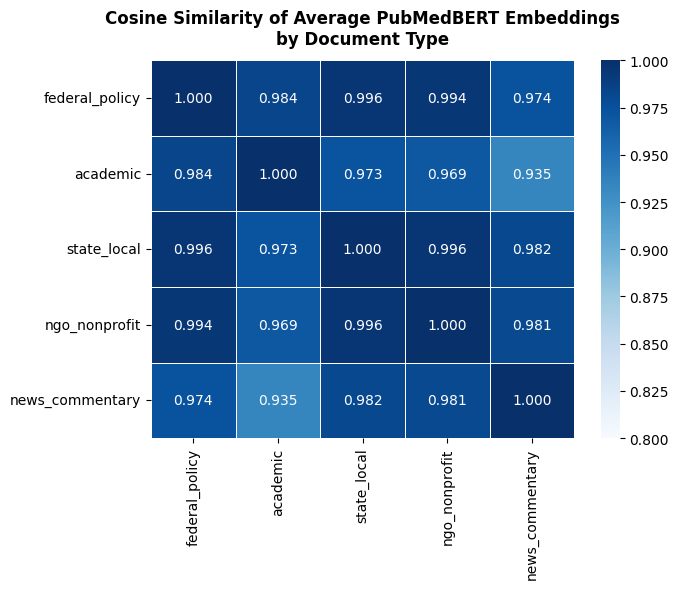

Saved: bert_similarity_heatmap.png


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    sim_df,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0.8,
    vmax=1.0,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)
ax.set_title(
    "Cosine Similarity of Average PubMedBERT Embeddings\nby Document Type",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
plt.tight_layout()
plt.savefig(
    "../03_main_analysis/bert_similarity_heatmap.png", bbox_inches="tight", dpi=150
)
plt.show()
print("Saved: bert_similarity_heatmap.png")

---
## Step 6 — Representative Examples per Cluster

In [8]:
print("=== Representative Examples per Cluster ===\n")

for cluster_id in sorted(df_valid["cluster"].unique()):
    cluster_data = df_valid[df_valid["cluster"] == cluster_id]
    print(f"--- Cluster {cluster_id} ({len(cluster_data):,} contexts) ---")
    print("Document type breakdown:")
    print(cluster_data["category"].value_counts().to_string())
    print("\nSample contexts:")
    samples = (
        cluster_data["sentence_text"]
        .sample(min(3, len(cluster_data)), random_state=42)
        .values
    )
    for j, s in enumerate(samples, 1):
        print(f"  [{j}] {s[:300]}")
    print()

=== Representative Examples per Cluster ===

--- Cluster 0 (2,612 contexts) ---
Document type breakdown:
category
state_local        1378
federal_policy      722
ngo_nonprofit       366
academic            127
news_commentary      19

Sample contexts:
  [1] Accomplishments resulting from this plan will be tracked and reported on quarterly through the Health Equity Working Group, and annual accomplishment reports will continue to be produced, which has been the practice since 2015.
  [2] Abstract Health equity-defined by the Centers for Disease Control and Prevention as " the state in which everyone has a fair and just opportunity to attain their highest level of health-" represents one of the most critical issues facing modern societies.
  [3] To improve equity in health care quality, CMS will continue to identify language, health literacy, and cultural needs among those we serve across different care settings, and strive to meet those needs.

--- Cluster 1 (1,428 contexts) ---
Documen

Cluster 0 (2,612 contexts) contains substantive, coherent sentences 
that discuss equity as a concept, goal, or institutional practice. 
Academic abstracts concentrate heavily in this cluster (127 out of 140 
academic sentences, or 91%), consistent with H1 — academic texts use 
equity in well-developed conceptual sentences. Federal policy and 
state/local documents also appear here in large numbers, suggesting 
that when these documents discuss equity substantively, their language 
overlaps with academic framing.

Cluster 1 (1,428 contexts) captures more fragmented uses of equity — 
document titles, table headers, bullet points, appendix references, 
and statistical comparisons. News commentary sentences (33) concentrate 
relatively more here, as do NGO documents (257). The near-absence of 
academic sentences in this cluster (only 13) reflects the more 
structured and complete nature of academic prose.

This finding complicates a simple structural vs. distributional 
interpretation of the clusters. Rather than separating two semantic 
framings of equity, PubMedBERT appears to have separated substantive 
equity discourse from referential or fragmentary equity mentions. This 
is itself an analytically meaningful result — it reveals that a 
substantial portion of equity language in policy and institutional 
documents appears in non-discursive contexts such as tables, plans, 
and titles, while academic usage is almost entirely discursive.

---
### Interpretation — Most Central Sentences per Cluster

The most central sentence for each cluster — the sentence whose embedding 
is closest to the cluster centroid — provides the clearest window into 
what each cluster semantically represents.

**Cluster 0** is most centrally represented by a sentence from the County 
of San Diego Health and Human Services Agency:
> *"Our plan to advance health equity aligns with, and is informed by, 
> the County's Live Well San Diego vision, and health equity efforts 
> globally, nationally, regionally, and in the state of California."*

This sentence is characteristic of Cluster 0's institutional, 
planning-oriented equity language — equity as an organizational 
commitment embedded in strategic frameworks and multi-level governance 
structures. The sentence is coherent, complete, and substantive, 
consistent with our earlier finding that Cluster 0 captures discursive 
equity language.

**Cluster 1** is most centrally represented by a sentence from Families 
USA:
> *"Advocates, on equity that includes disaggregate outcomes 
> decision-makers, and other health care stakeholders data as a central 
> research objective."*

This sentence is notably fragmented — it reads like a bullet point or 
table cell extracted from a structured document rather than a complete 
discursive sentence. This is consistent with our earlier finding that 
Cluster 1 captures more fragmentary, referential uses of equity — 
document titles, bullet points, appendix references, and data tables — 
rather than fully developed equity discourse.

Together, the most central sentences reinforce the interpretation that 
PubMedBERT has separated substantive equity discourse (Cluster 0) from 
fragmentary equity references (Cluster 1), rather than separating 
structural from distributional framings as originally hypothesized.

In [9]:
# Find most representative sentence per cluster (closest to centroid)
print("=== Most Representative Sentences per Cluster ===\n")

for cluster_id in sorted(df_valid["cluster"].unique()):
    mask = df_valid["cluster"] == cluster_id
    cluster_embeddings = embeddings_norm[mask]
    centroid = cluster_embeddings.mean(axis=0)

    # Distance from centroid
    distances = cosine_similarity([centroid], cluster_embeddings)[0]
    most_central_idx = distances.argmax()

    cluster_df = df_valid[mask].reset_index(drop=True)
    most_central = cluster_df.iloc[most_central_idx]

    print(f"--- Cluster {cluster_id} ---")
    print(f"Category: {most_central['category']}")
    print(f"Source: {most_central['source_label']}")
    print(f"Sentence: {most_central['sentence_text'][:300]}")
    print()

=== Most Representative Sentences per Cluster ===

--- Cluster 0 ---
Category: state_local
Source: County of San Diego Health and Human Services Agency
Sentence: Our plan to Services advance health equity aligns with, and is informed by, the County's Live Well San Diego vision, and health equity efforts globally, nationally, regionally, and in the state of California.

--- Cluster 1 ---
Category: ngo_nonprofit
Source: Families USA
Sentence: Advocates, on equity that includes disaggregate outcomes decision-makers, and other health care stakeholders data as a central research objective.



---
### Interpretation — Definition Sentences Across Clusters

The corpus contains 151 sentences flagged as definition sentences — 
sentences that explicitly define equity using phrases such as "health 
equity is defined as" or "we define equity as." These sentences are 
analytically important because they represent the most deliberate and 
explicit framings of the concept.

**Key finding:** Definition sentences concentrate overwhelmingly in 
Cluster 0 (109 out of 151, or 72%). This strongly supports the 
interpretation that Cluster 0 captures substantive equity discourse — 
sentences that engage with equity as a concept rather than merely 
referencing it in passing.

**By document type:**
- State/local health departments produce the most definition sentences 
  (53 in Cluster 0, 31 in Cluster 1), reflecting the common practice 
  in health department reports of opening sections with formal equity 
  definitions before presenting data
- Federal policy documents have 34 definition sentences in Cluster 0 
  and only 5 in Cluster 1 — a strong 87% concentration in the 
  substantive cluster
- Academic texts have 12 definition sentences in Cluster 0 and only 
  1 in Cluster 1 — a 92% concentration, the highest of any category
- NGO documents split more evenly (9 vs 5), suggesting that NGO 
  equity definitions sometimes appear in more fragmentary contexts 
  such as report appendices or reference sections

The near-total absence of definition sentences in Cluster 1 (42 out 
of 151, or 28%) validates the cluster interpretation: Cluster 1 
captures equity language that is too fragmented or decontextualized 
to constitute a proper definition. This finding also has methodological 
implications — if you wanted to study how equity is formally defined 
across document types, filtering to Cluster 0 definition sentences 
would give you the cleanest analytical subset.

In [10]:
# Cluster distribution for definition sentences only
def_sentences = df_valid[df_valid["is_definition_sentence"] == True]
non_def_sentences = df_valid[df_valid["is_definition_sentence"] == False]

print("=== Definition Sentences — Cluster Distribution ===")
print(def_sentences["cluster"].value_counts())
print(f"Total definition sentences: {len(def_sentences)}")
print()
print("=== Non-Definition Sentences — Cluster Distribution ===")
print(non_def_sentences["cluster"].value_counts())
print()
print("=== Definition Sentences by Category ===")
print(pd.crosstab(def_sentences["category"], def_sentences["cluster"]))

=== Definition Sentences — Cluster Distribution ===
cluster
0    109
1     42
Name: count, dtype: int64
Total definition sentences: 151

=== Non-Definition Sentences — Cluster Distribution ===
cluster
0    2503
1    1386
Name: count, dtype: int64

=== Definition Sentences by Category ===
cluster           0   1
category               
academic         12   1
federal_policy   34   5
news_commentary   1   0
ngo_nonprofit     9   5
state_local      53  31


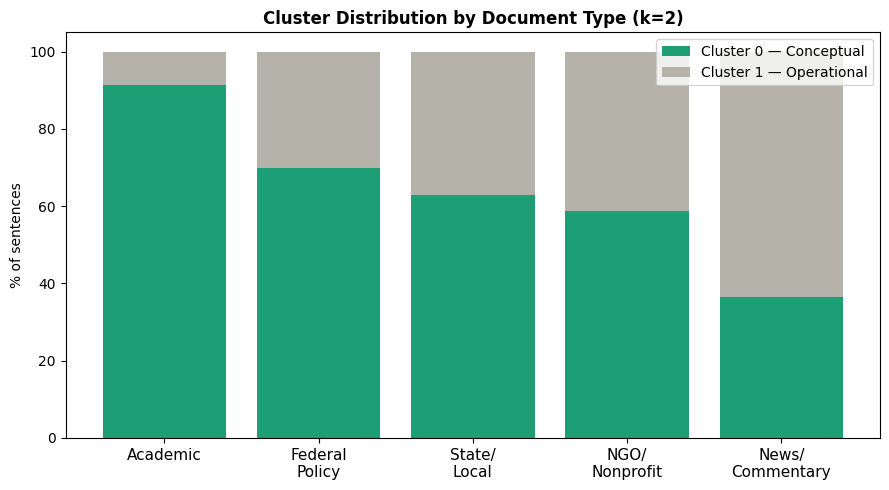

In [11]:
import matplotlib.pyplot as plt
import numpy as np

cats = [
    "Academic",
    "Federal\nPolicy",
    "State/\nLocal",
    "NGO/\nNonprofit",
    "News/\nCommentary",
]
c0 = [91.4, 70.0, 62.8, 58.7, 36.5]
c1 = [8.6, 30.0, 37.2, 41.3, 63.5]

x = np.arange(len(cats))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x, c0, label="Cluster 0 — Conceptual", color="#1D9E75")
ax.bar(x, c1, bottom=c0, label="Cluster 1 — Operational", color="#B4B2A9")
ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=11)
ax.set_ylabel("% of sentences")
ax.set_title("Cluster Distribution by Document Type (k=2)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("cluster_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 7 — UMAP Dimensionality Reduction

BERT embeddings exist in a 768-dimensional space which cannot be directly visualized. 
We use UMAP (Uniform Manifold Approximation and Projection) to compress these 
768-dimensional vectors into 2 dimensions while preserving the relative distances 
between points as much as possible.

The key property of UMAP for this project is that sentences whose *equity* embeddings 
were close together in 768-dimensional space — meaning BERT encoded them similarly — 
will appear close together in the 2D projection. This allows us to visually inspect 
whether distinct semantic clusters emerge and whether they align with document types.

**Important note on interpretation:** The X and Y axis values produced by UMAP are 
arbitrary — their absolute values carry no meaning. What is meaningful is the *relative 
position* of points to each other. The resulting 2D coordinates are exported alongside 
the cluster assignments and sentence metadata for interactive visualization in Tableau, 
where zooming into a region reveals which specific documents and sources populate that 
area of the semantic space.

**Parameters:**
- `n_neighbors=15` — controls how much local vs. global structure is preserved
- `min_dist=0.1` — controls how tightly points are packed together in 2D
- `random_state=42` — ensures reproducibility


In [12]:
import umap

print("Running UMAP...")
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
embedding_2d = reducer.fit_transform(embeddings_norm)

df_valid["umap_x"] = embedding_2d[:, 0]
df_valid["umap_y"] = embedding_2d[:, 1]
print("UMAP done.")

Running UMAP...


/Users/sebinescaria/miniforge3/envs/equity_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP done.


In [13]:
tableau_df = df_valid[
    [
        "sentence_text",
        "category",
        "source_label",
        "title",
        "document_subtype",
        "is_definition_sentence",
        "contains_health_equity",
        "word_count",
        "cluster",
        "umap_x",
        "umap_y",
    ]
].copy()

tableau_df.to_csv("../04_visualizations/equity_tableau.csv", index=False)
print(f"Exported {len(tableau_df):,} rows to equity_tableau.csv")
print(f"Columns: {tableau_df.columns.tolist()}")

Exported 4,040 rows to equity_tableau.csv
Columns: ['sentence_text', 'category', 'source_label', 'title', 'document_subtype', 'is_definition_sentence', 'contains_health_equity', 'word_count', 'cluster', 'umap_x', 'umap_y']
